# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately!



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission.
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values.

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [1]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.**

For a detailed description of the dataset features, please refer to  **Appendix 1** below.

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split.

In [2]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data;
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:**

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?


The business objective is to build an accurate and automated valuation engine that predicts the assessed tax value of a property based on its physical and geographic characteristics. Currently, such evaluations require expensive and time-consuming manual appraisals, sometimes requiring an on-site visit. By automating this process with machine learning, Zillow can create an efficient data solution to sell to clients such as local governments, mortgage lenders, and real estate investors who need to evaluate thousands of properties instantly.

**1.2:**  How will your solution be used?


Since our target clientbase includes local governments, mortgage lenders, and real estate investment firms, our regression model would be made available as an API (Application Programming Interface). When the client needs to know a property’s assessed value (such as when a municipality is generating their annual property tax bills), they can feed the home’s features (e.g., square footage, bedroom count, location) into our system. The model will instantly return a predicted tax value.

**1.3:**  How should success (or failure) be measured?


Success should be measured both mathematically and commercially. Mathematically, we should use a metric like Mean Absolute Error or Root Mean Squared Error, which would tell us how many dollars off our prediction is on average. If our model consistently predicts values within an acceptable margin of error (e.g., within $10,000 of a manually-calculated appraisal), the algorithm is considered a success. Commercially, success will be measured by the adoption rate of our API.

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process.
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [3]:
df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  finishedsqua

In [5]:
# Get count of unique values per column

df.nunique()

parcelid                        77414
airconditioningtypeid               5
architecturalstyletypeid            5
basementsqft                       43
bathroomcnt                        22
bedroomcnt                         16
buildingclasstypeid                 2
buildingqualitytypeid              12
calculatedbathnbr                  21
decktypeid                          1
finishedfloor1squarefeet         1787
calculatedfinishedsquarefeet     4972
finishedsquarefeet12             4868
finishedsquarefeet13               13
finishedsquarefeet15             1724
finishedsquarefeet50             1807
finishedsquarefeet6               350
fips                                3
fireplacecnt                        5
fullbathcnt                        13
garagecarcnt                       14
garagetotalsqft                   839
hashottuborspa                      1
heatingorsystemtypeid              10
latitude                        64038
longitude                       62461
lotsizesquar

In [6]:
# Sort columns by count of unique values

unique_counts = df.nunique()

unique_report = pd.DataFrame({"Unique Values": unique_counts})

# Sort from lowest to highest
unique_report = unique_report.sort_values(by="Unique Values")

print(unique_report)

                              Unique Values
poolcnt                                   1
storytypeid                               1
pooltypeid7                               1
pooltypeid2                               1
pooltypeid10                              1
fireplaceflag                             1
hashottuborspa                            1
decktypeid                                1
taxdelinquencyflag                        1
assessmentyear                            1
buildingclasstypeid                       2
regionidcounty                            3
fips                                      3
numberofstories                           4
typeconstructiontypeid                    4
threequarterbathnbr                       4
airconditioningtypeid                     5
architecturalstyletypeid                  5
fireplacecnt                              5
unitcnt                                   8
heatingorsystemtypeid                    10
buildingqualitytypeid           

In [7]:
# Identify categorical features by dtype

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Categorical features (based on dtype):", categorical_cols)

Categorical features (based on dtype): ['hashottuborspa', 'propertycountylandusecode', 'propertyzoningdesc', 'fireplaceflag', 'taxdelinquencyflag']


/var/folders/vd/9lr0_frd09vcgh0p1zt98rqc0000gn/T/ipykernel_59555/2865992181.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


In [8]:
# Find all columns that contain the string "id" in their name
id_columns = [col for col in df.columns if "id" in col.lower()]

# Print the list to cross-reference with Appendix 1 and assess categorical vs. numerical
print(id_columns)

['parcelid', 'airconditioningtypeid', 'architecturalstyletypeid', 'buildingclasstypeid', 'buildingqualitytypeid', 'decktypeid', 'heatingorsystemtypeid', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7', 'propertylandusetypeid', 'regionidcity', 'regionidcounty', 'regionidneighborhood', 'regionidzip', 'storytypeid', 'typeconstructiontypeid']


In [9]:
# Final list of categorical features

categorical_features = [
    "hashottuborspa",
    "propertycountylandusecode",
    "propertyzoningdesc",
    "fireplaceflag",
    "taxdelinquencyflag",
    "airconditioningtypeid",
    "architecturalstyletypeid",
    "buildingclasstypeid",
    "typeconstructiontypeid",
    "regionidcounty",
    "fips",
    "decktypeid",
    "pooltypeid10",
    "pooltypeid2",
    "pooltypeid7",
    "storytypeid",
    "assessmentyear",
    "buildingqualitytypeid",
    "heatingorsystemtypeid",
    "propertylandusetypeid",
    "regionidcity",
    "regionidneighborhood",
    "regionidzip",
    "rawcensustractandblock",
    "censustractandblock"
]


In [10]:
# Sort columns by percentage of missing values

missing_counts = df.isnull().sum()

missing_percentages = (missing_counts / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Count": missing_counts,
    "Percentage (%)": missing_percentages
})

# Sort from highest to lowest
missing_report = missing_report.sort_values(by="Missing Count", ascending=False)

print(missing_report)

                              Missing Count  Percentage (%)
buildingclasstypeid                   77598       99.980673
finishedsquarefeet13                  77571       99.945885
storytypeid                           77563       99.935578
basementsqft                          77563       99.935578
yardbuildingsqft26                    77543       99.909809
fireplaceflag                         77441       99.778388
architecturalstyletypeid              77406       99.733292
typeconstructiontypeid                77390       99.712677
finishedsquarefeet6                   77227       99.502661
pooltypeid10                          77148       99.400874
decktypeid                            76999       99.208895
poolsizesum                           76744       98.880342
pooltypeid2                           76539       98.616211
hashottuborspa                        76074       98.017085
yardbuildingsqft17                    75220       96.916754
taxdelinquencyflag                    74

#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

The following features have dtype of either "object" or "string":

- hashottuborspa
- propertycountylandusecode
- propertyzoningdesc
- fireplaceflag
- taxdelinquencyflag

Per Appendix 1, the following features are just ID tags or geographical codes:

- airconditioningtypeid
- architecturalstyletypeid
- buildingclasstypeid
- typeconstructiontypeid
- regionidcounty
- fips

The following features have just 1 unique value. Per Appendix 1, they are identifiers for specific features, making these essentially binary categoricals:

- decktypeid
- pooltypeid10
- pooltypeid2
- pooltypeid7
- storytypeid

Years are typically treated as categorical or ordinal data,  so we will consider `assessmentyear` as a categorical feature.

Some features contained "id" in their name. For these instances, we cross-referenced with Appendix 1 to confirm that identifiers are treated as categorical features:

- buildingqualitytypeid
- heatingorsystemtypeid
- propertylandusetypeid
- regionidcity
- regionidneighborhood
- regionidzip

Appendix 1 indicated that `rawcensustractandblock` and `censustractandblock` are geographic codes rather than continuous values.

Based on the above, here is the final **list of categorical features**:

- hashottuborspa
- propertycountylandusecode
- propertyzoningdesc
- fireplaceflag
- taxdelinquencyflag
- airconditioningtypeid
- architecturalstyletypeid
- buildingclasstypeid
- typeconstructiontypeid
- regionidcounty
- fips
- decktypeid
- pooltypeid10
- pooltypeid2
- pooltypeid7
- storytypeid
- assessmentyear
- buildingqualitytypeid
- heatingorsystemtypeid
- propertylandusetypeid
- regionidcity
- regionidneighborhood
- regionidzip
- rawcensustractandblock
- censustractandblock

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly.

At first glance, any features that do not describe the physical or geographical characteristics of the property appear useless for our business goal. For example, `parcelid` is a unique identifier from which a machine learning model cannot make meaningful predictions. Another example is `assessmentyear` because our EDA revealed it has only one unique value, and knowing that every property in the dataset was assessed in the same year does not help differentiate high-value from low-value properties. Per Appendix 1, `rawcensustractandblock` and `censustractandblock` are likely redundant as the latter is a combined version of the former. Additionally, there are other location identifiers available that are probably easier to use, like `regionidcity` and `regionidzip`.

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example.

The following features are likely useless because they have high percentages of missing values and an empty value cannot be safely imputed with 0:

- buildingclasstypeid (99.9% missing)
- architecturalstyletypeid (99.7% missing)
- regionidneighborhood (60% missing)

There are other features with high percentages of missing values, but based on Appendix 1, these represent missing amenities and it may be possible to impute them rather than drop them. Examples include `poolcnt`, `fireplacecnt`, `hashottuborspa`, and `garagecarcnt`.

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example.

To assess which features are likely useless based on the number of unique values, we looked for columns with only 1 unique value (potentially constant variables) and columns with potentially too many unique values:

- **assessmentyear**: Its unique value count is 1, which means every single property in the dataset was assessed in the same year. This provides no predictive power.
- **parcelid**: Its unique value count is 77,414, roughly equal to the number of rows in the dataset. Per Appendix 1, this column is just the primary key. A model cannot predict the target based on a randomly assigned ID.

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

In [11]:
# Create a list of numerical features by excluding categoricals, primary ID column, and target variable
numerical_features = [
    col for col in df.columns
    if col not in categorical_features
    and col != "parcelid"
    and col != "taxvaluedollarcnt"
]

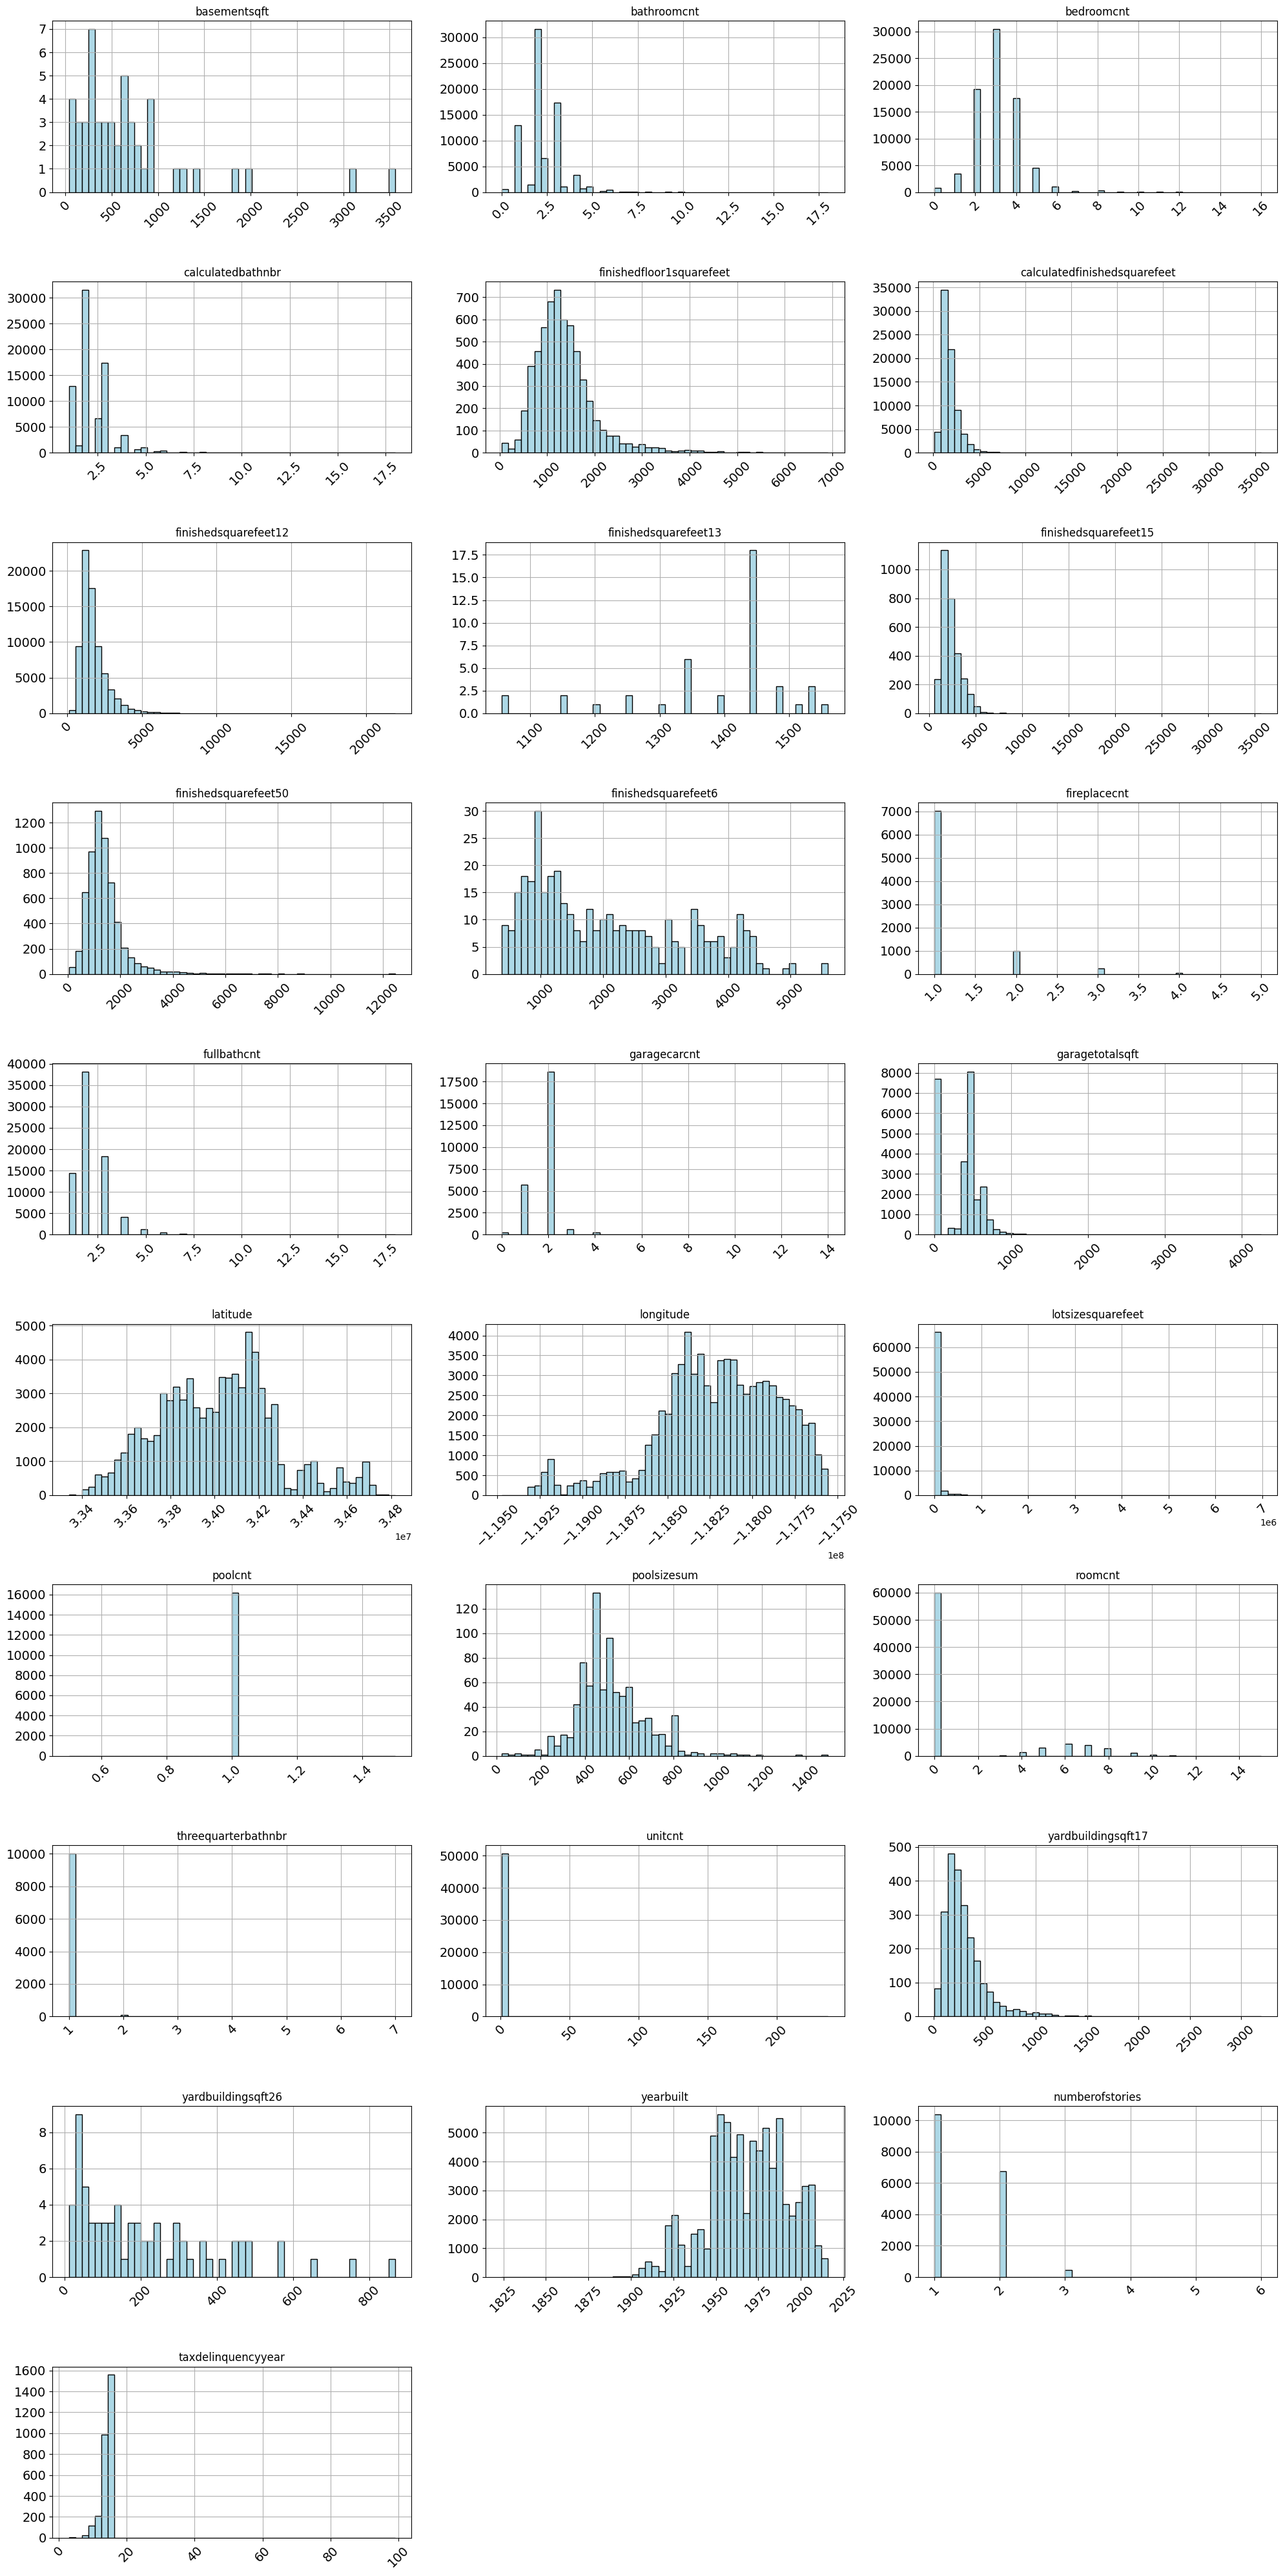

In [12]:
# Plot histograms for each numerical feature, 3 per row

df[numerical_features].hist(
    figsize=(20, 40),
    bins=50,
    layout=(-1, 3),
    color="lightblue",
    edgecolor="black",
    xlabelsize=14,
    ylabelsize=14,
    xrot=45
)

plt.tight_layout()

In [13]:
# Define the target and 3 features for feature-level visualizations

target = "taxvaluedollarcnt"
feat1 = "calculatedfinishedsquarefeet"
feat2 = "bedroomcnt"
feat3 = "buildingqualitytypeid"

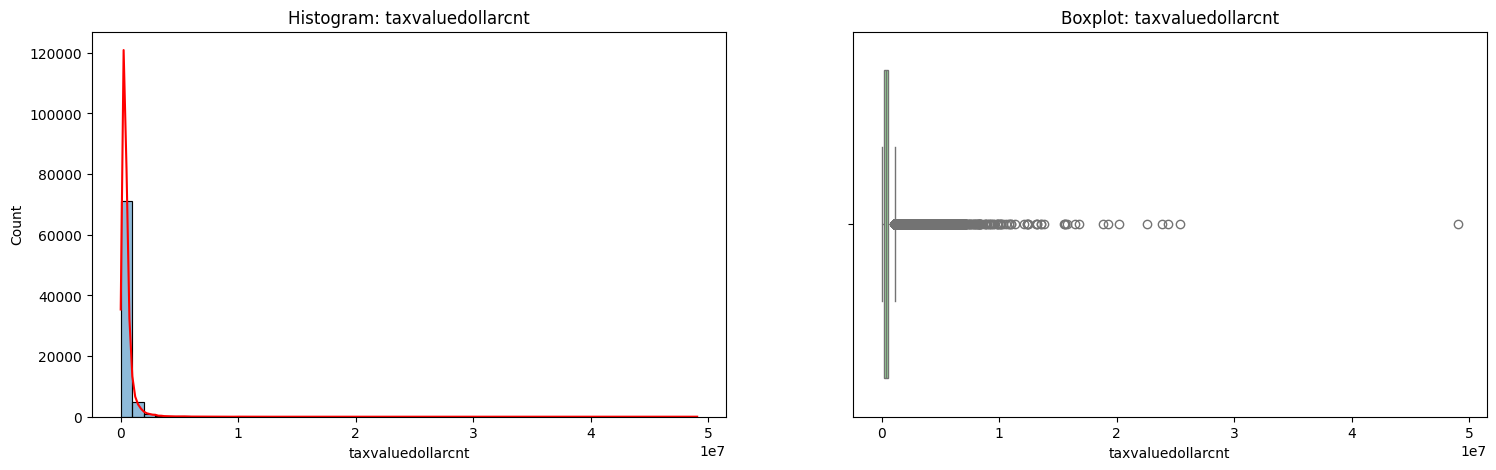

In [14]:
# Visualizing target variable taxvaluedollarcnt

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Left: Histogram for distribution
sns.histplot(data=df, x=target, bins=50, kde=True, ax=axes[0])
if len(axes[0].lines) > 0: axes[0].lines[0].set_color("red") # Force red curve
axes[0].set_title(f"Histogram: {target}")

# Right: Boxplot for outliers
sns.boxplot(data=df, x=target, color="lightgreen", ax=axes[1])
axes[1].set_title(f"Boxplot: {target}")
plt.show()

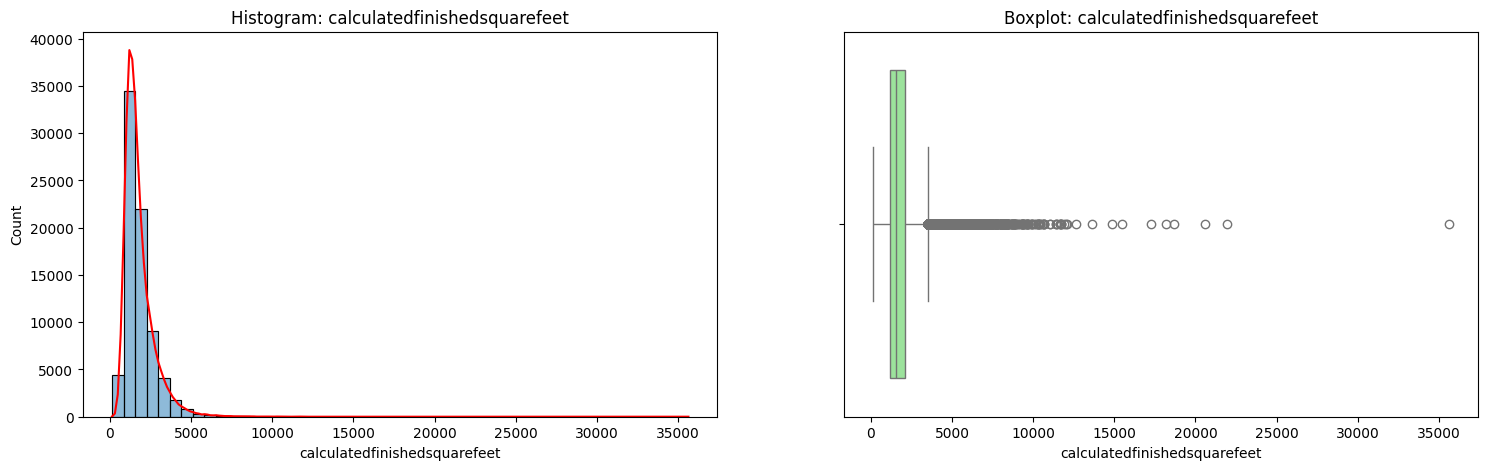

In [15]:
# Visualizing feature 1 calculatedfinishedsquarefeet

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Left: Histogram for distribution
sns.histplot(data=df, x=feat1, bins=50, kde=True, ax=axes[0])
if len(axes[0].lines) > 0: axes[0].lines[0].set_color("red")
axes[0].set_title(f"Histogram: {feat1}")

# Right: Boxplot for outliers
sns.boxplot(data=df, x=feat1, color="lightgreen", ax=axes[1])
axes[1].set_title(f"Boxplot: {feat1}")
plt.show()

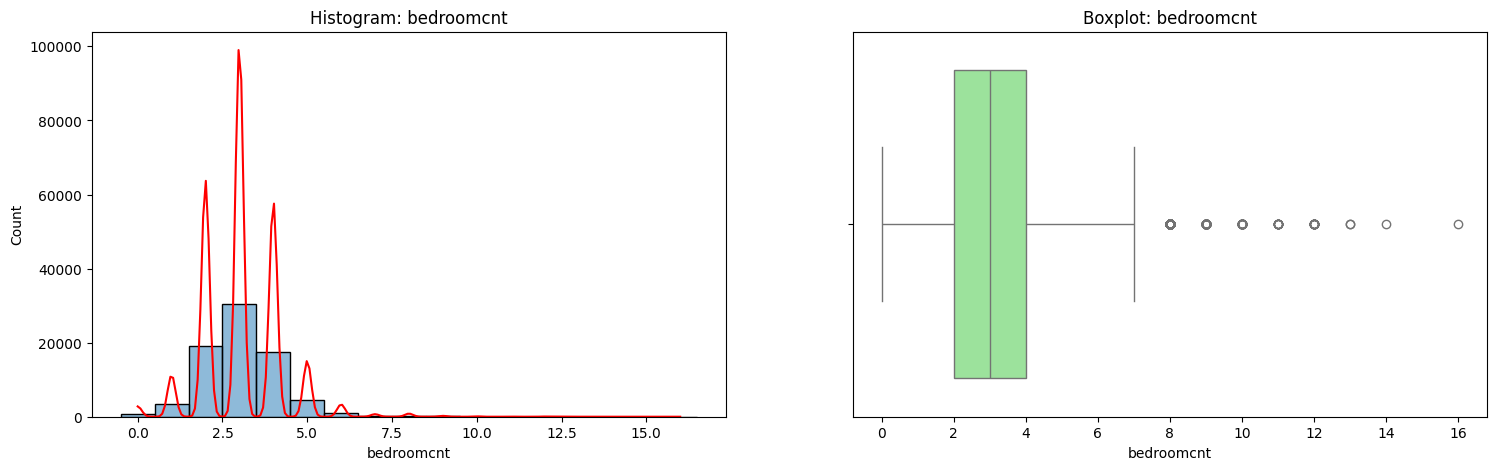

In [16]:
# Visualizing feature 2 bedroomcnt

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Left: Histogram for distributions
sns.histplot(data=df, x=feat2, discrete=True, kde=True, ax=axes[0]) # discrete=True because you can't have 2.5 bedrooms
if len(axes[0].lines) > 0: axes[0].lines[0].set_color("red")
axes[0].set_title(f"Histogram: {feat2}")

# Right: Boxplot for outliers
sns.boxplot(data=df, x=feat2, color="lightgreen", ax=axes[1])
axes[1].set_title(f"Boxplot: {feat2}")
plt.show()

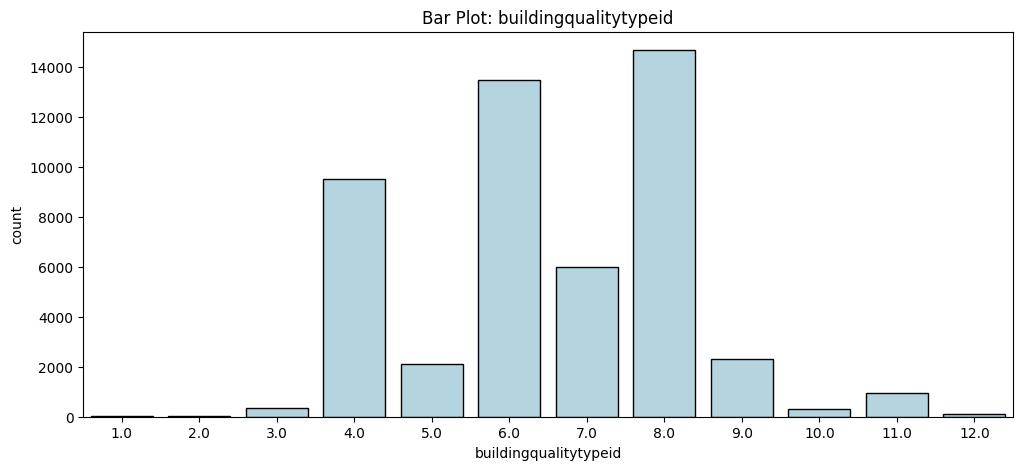

In [17]:
# Visualizing feature 3 buildingqualitytypeid

fig, ax = plt.subplots(figsize=(12, 5))

# Bar plot because categorical feature
sns.countplot(data=df, x=feat3, ax=ax, edgecolor="black", color="lightblue")
ax.set_title(f"Bar Plot: {feat3}")
plt.show()

#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?


For our detailed examination, we took a closer look at the target variable (`taxvaluedollarcnt`) and the following three features: `calculatedfinishedsquarefeet`, `bedroomcnt`, and `buildingqualitytypeid`. We chose these specific features because we suspect they are strong predictors of assessed property value and to explore a mix of continuous, discrete, and categorical data. The distributions for `taxvaluedollarcnt` and `calculatedfinishedsquarefeet` were severely right-skewed. Their boxplots were also extremely compressed, barely visible, with many dots representing the presence of extreme outliers. This makes sense because in real estate, most homes cluster around a median price/size, with a small number of "mega mansions" or luxury homes exceeding the norm. The bedroom count (`bedroomcnt`) follows a roughly normal distribution, centering around 3 to 4 bedrooms. Interestingly, because this is discrete data (no such thing as 0.5 bedrooms), the KDE curve looks like a “rollercoaster” as it tries to apply a continuous smoothing function. The boxplot indicates potential outliers, such as mansions with 10+ bedrooms. The distribution of `buildingqualitytypeid` is very imbalanced, with some quality ratings (namely 4, 6, and 8) dominating the dataset, while others (like 1, 2, and 12) are practically non-existent. Those extremely rare categories are our outliers.

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task!

In [18]:
# ================================================================
# Part 3.A: Drop features unsuitable for the regression task
# (NOT because of missing values — that's 3.B)
# ================================================================

def drop_unsuitable_features(df):
    """
    Drop columns that are fundamentally unsuitable for predicting
    taxvaluedollarcnt, regardless of their missing-value rate.
    """
    cols_to_drop = [
        'parcelid',                  # Primary key — random ID, no predictive signal
        'assessmentyear',            # Zero variance: only 1 unique value
        'rawcensustractandblock',    # Redundant: censustractandblock is the processed version
        'propertyzoningdesc',        # 1,907 unique text strings — impractical to encode
        'propertycountylandusecode', # 75 unique text codes — redundant with propertylandusetypeid
    ]
    existing = [c for c in cols_to_drop if c in df.columns]
    df_out = df.drop(columns=existing)
    print(f"Dropped {len(existing)} features: {existing}")
    print(f"Shape: {df.shape} → {df_out.shape}")
    return df_out

df_a = drop_unsuitable_features(df)

Dropped 5 features: ['parcelid', 'assessmentyear', 'rawcensustractandblock', 'propertyzoningdesc', 'propertycountylandusecode']
Shape: (77613, 55) → (77613, 50)


#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop.


We dropped 5 features that are fundamentally unsuitable for predicting property value. `parcelid` is a unique record identifier with no predictive signal. `assessmentyear` has zero variance — every property was assessed in the same year, so it cannot differentiate high-value from low-value properties. `rawcensustractandblock` is the unprocessed precursor to `censustractandblock`; keeping both introduces redundancy. `propertyzoningdesc` contains 1,907 unique free-text strings — far too high-cardinality to encode meaningfully without domain expertise. Similarly, `propertycountylandusecode` has 75 unique text codes effectively covered by the numeric `propertylandusetypeid`.

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully.

In [19]:
# ================================================================
# Part 3.B: Drop features with too many null values (threshold = 50%)
#
# Exception: amenity count features where NaN almost certainly means
# "this property has none of that amenity" (i.e., correct value = 0).
# We keep those for imputation in 3.D instead of dropping them.
# ================================================================

MISSING_THRESHOLD = 0.50

# NaN in these columns means "no pool / no garage" — impute with 0 in 3.D
AMENITY_COLS = ['poolcnt', 'garagecarcnt', 'garagetotalsqft']

def drop_high_missing_features(df, threshold=MISSING_THRESHOLD, keep_cols=None):
    """
    Drop columns where fraction of null values exceeds `threshold`,
    unless the column is in `keep_cols`.
    """
    if keep_cols is None:
        keep_cols = []
    missing_frac = df.isnull().mean()
    cols_to_drop = [
        col for col in df.columns
        if missing_frac[col] > threshold and col not in keep_cols
    ]
    df_out = df.drop(columns=cols_to_drop)
    print(f"Dropped {len(cols_to_drop)} features with >{threshold*100:.0f}% missing:\n")
    for c in sorted(cols_to_drop, key=lambda c: missing_frac[c], reverse=True):
        print(f"  {c}: {missing_frac[c]*100:.1f}%")
    print(f"\nShape: {df.shape} → {df_out.shape}")
    return df_out

df_b = drop_high_missing_features(df_a, threshold=MISSING_THRESHOLD, keep_cols=AMENITY_COLS)

Dropped 26 features with >50% missing:

  buildingclasstypeid: 100.0%
  finishedsquarefeet13: 99.9%
  basementsqft: 99.9%
  storytypeid: 99.9%
  yardbuildingsqft26: 99.9%
  fireplaceflag: 99.8%
  architecturalstyletypeid: 99.7%
  typeconstructiontypeid: 99.7%
  finishedsquarefeet6: 99.5%
  pooltypeid10: 99.4%
  decktypeid: 99.2%
  poolsizesum: 98.9%
  pooltypeid2: 98.6%
  hashottuborspa: 98.0%
  yardbuildingsqft17: 96.9%
  taxdelinquencyflag: 96.3%
  taxdelinquencyyear: 96.3%
  finishedsquarefeet15: 96.1%
  finishedfloor1squarefeet: 92.2%
  finishedsquarefeet50: 92.2%
  fireplacecnt: 89.3%
  threequarterbathnbr: 87.0%
  pooltypeid7: 80.6%
  numberofstories: 77.3%
  airconditioningtypeid: 67.8%
  regionidneighborhood: 60.1%

Shape: (77613, 50) → (77613, 24)


#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped



We applied a 50% missing-value threshold to drop features where imputation would introduce more noise than signal. Columns like `buildingclasstypeid` (99.98% missing) and `architecturalstyletypeid` (99.73% missing) have so few non-null values that any imputed value would dominate the column entirely. This removed 26 features. We made a deliberate exception for three amenity count features — `poolcnt` (79.2% missing), `garagecarcnt` (67.1%), and `garagetotalsqft` (67.1%) — because a missing value in these columns almost certainly means the property has no pool or garage, making 0 a correct and interpretable imputed value rather than an arbitrary one.

### Part 3.C: Drop Problematic **samples**

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [20]:
# ================================================================
# Part 3.C: Drop problematic rows
#   1. Rows with a null target value
#   2. Rows missing more than 50% of remaining features
#   3. Rows with extreme outliers in the target
# ================================================================

def drop_problematic_samples(df, target='taxvaluedollarcnt',
                              max_row_null_frac=0.50,
                              iqr_multiplier=5.0):
    """
    Remove samples that would corrupt model training.
    """
    df_clean = df.copy()
    n = len(df_clean)

    # 1. Drop rows with no target value
    df_clean = df_clean.dropna(subset=[target])
    print(f"Dropped {n - len(df_clean):,} rows with null target")
    n = len(df_clean)

    # 2. Drop rows where >50% of features are null
    row_null_frac = df_clean.drop(columns=[target]).isnull().mean(axis=1)
    df_clean = df_clean[row_null_frac <= max_row_null_frac]
    print(f"Dropped {n - len(df_clean):,} rows with >{max_row_null_frac*100:.0f}% null features")
    n = len(df_clean)

    # 3. Remove extreme target outliers using a wide IQR fence (5x)
    Q1 = df_clean[target].quantile(0.25)
    Q3 = df_clean[target].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - iqr_multiplier * IQR, Q3 + iqr_multiplier * IQR
    df_clean = df_clean[df_clean[target].between(lo, hi)]
    print(f"Dropped {n - len(df_clean):,} rows with extreme target outliers")
    print(f"  Target bounds: [${lo:,.0f}, ${hi:,.0f}]")
    print(f"\nFinal shape: {df_clean.shape}")
    return df_clean

df_c = drop_problematic_samples(df_b)

Dropped 35 rows with null target
Dropped 91 rows with >50% null features
Dropped 1,094 rows with extreme target outliers
  Target bounds: [$-1,603,430, $2,379,516]

Final shape: (76393, 24)


#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped


We removed samples for three reasons. First, the 35 rows with a null target were dropped — there is nothing to learn from unlabeled examples. Second, rows where more than 50% of the remaining features were null were removed, since imputing the majority of a row's values would make that sample almost synthetic. Third, we removed extreme outliers in `taxvaluedollarcnt` using an IQR multiplier of 5.0 (rather than the standard 1.5). We chose a wider fence deliberately: as seen in Part 2, the right skew in property values includes legitimate luxury properties that are rare but real. An overly tight cutoff would discard valid high-end properties and distort the model.

### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [21]:
# ================================================================
# Part 3.D: Impute remaining missing values
#
# Strategy by column type:
#   - Amenity count cols (poolcnt, garagecarcnt, garagetotalsqft): fill with 0
#   - Categorical / ID cols: fill with mode
#   - All other numeric cols (skewed distributions): fill with median
# ================================================================

# Categorical ID columns still present after 3A/3B
CATEGORICAL_ID_COLS = [
    'buildingqualitytypeid', 'heatingorsystemtypeid', 'propertylandusetypeid',
    'regionidcity', 'regionidzip', 'regionidcounty', 'censustractandblock',
    'fips', 'unitcnt',
]

def impute_missing_values(df, amenity_cols, categorical_cols):
    """
    Impute missing values with strategies appropriate to each column type.
    Returns the imputed dataframe.
    """
    df_imp = df.copy()

    # 1. Amenity cols → 0 (absence of amenity)
    for col in amenity_cols:
        if col in df_imp.columns and df_imp[col].isnull().any():
            df_imp[col] = df_imp[col].fillna(0)
            print(f"  [0]      {col}")

    # 2. Categorical ID cols → mode
    for col in categorical_cols:
        if col in df_imp.columns and df_imp[col].isnull().any():
            mode_val = df_imp[col].mode()[0]
            df_imp[col] = df_imp[col].fillna(mode_val)
            print(f"  [mode={mode_val}]  {col}")

    # 3. Remaining numeric cols → median (robust to skew/outliers)
    numeric_cols = df_imp.select_dtypes(include=[np.number]).columns
    skip = set(amenity_cols + categorical_cols + ['taxvaluedollarcnt'])
    for col in numeric_cols:
        if col not in skip and df_imp[col].isnull().any():
            med = df_imp[col].median()
            df_imp[col] = df_imp[col].fillna(med)
            print(f"  [median={med:.2f}]  {col}")

    remaining_nulls = df_imp.isnull().sum().sum()
    print(f"\nTotal null values remaining: {remaining_nulls}")
    return df_imp

df_d = impute_missing_values(df_c, AMENITY_COLS, CATEGORICAL_ID_COLS)

  [0]      poolcnt
  [0]      garagecarcnt
  [0]      garagetotalsqft
  [mode=8.0]  buildingqualitytypeid
  [mode=2.0]  heatingorsystemtypeid
  [mode=12447.0]  regionidcity
  [mode=97319.0]  regionidzip
  [mode=60371371031000.0]  censustractandblock
  [mode=1.0]  unitcnt
  [median=2.00]  calculatedbathnbr
  [median=1533.00]  calculatedfinishedsquarefeet
  [median=1512.00]  finishedsquarefeet12
  [median=2.00]  fullbathcnt
  [median=7200.00]  lotsizesquarefeet
  [median=1970.00]  yearbuilt

Total null values remaining: 0


#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset


We used three imputation strategies based on the semantic meaning of each feature's missing values. For amenity count features (`poolcnt`, `garagecarcnt`, `garagetotalsqft`), we imputed with 0 — the absence of a value most plausibly means the property has no pool or garage. For categorical ID features (`heatingorsystemtypeid`, `buildingqualitytypeid`, `unitcnt`, etc.), we imputed with the mode, assigning the most common category to avoid inventing values that could shift the distribution. For all remaining numeric features (continuous measurements like `calculatedfinishedsquarefeet`, `lotsizesquarefeet`, `yearbuilt`), we used median imputation, which is robust to the heavy right-skew observed in Part 2 and is not distorted by extreme outliers.

### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary.

In [22]:
# ================================================================
# Part 3.E: Encode categorical features
#
# After 3.A and 3.B, all object-type columns (hashottuborspa,
# fireplaceflag, taxdelinquencyflag, etc.) have been dropped.
# The remaining categorical features are already stored as numeric IDs.
#
# We apply OrdinalEncoder so they are stored as clean 0-based integers,
# which is important for linear models and consistent preprocessing.
# ================================================================


def encode_categorical_features(df, categorical_cols):
    """
    Apply OrdinalEncoder to categorical ID columns.
    Already-numeric IDs are re-encoded as clean 0-based integers.
    """
    df_enc = df.copy()
    existing = [c for c in categorical_cols if c in df_enc.columns]

    if not existing:
        print("No remaining object-type categorical features — all already numeric.")
        return df_enc, None

    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    df_enc[existing] = encoder.fit_transform(df_enc[existing].astype(str))
    print(f"Encoded {len(existing)} categorical features using OrdinalEncoder:")
    for c in existing:
        n_cats = df_enc[c].nunique()
        print(f"  {c}: {n_cats} categories")
    return df_enc, encoder

df_e, cat_encoder = encode_categorical_features(df_d, CATEGORICAL_ID_COLS)

# Final summary
print(f"\n{'='*50}")
print(f"Final cleaned dataset shape: {df_e.shape}")
print(f"Null values remaining:       {df_e.isnull().sum().sum()}")
print(f"{'='*50}")
df_e.head()

Encoded 9 categorical features using OrdinalEncoder:
  buildingqualitytypeid: 12 categories
  heatingorsystemtypeid: 10 categories
  propertylandusetypeid: 13 categories
  regionidcity: 175 categories
  regionidzip: 389 categories
  regionidcounty: 3 categories
  censustractandblock: 38597 categories
  fips: 3 categories
  unitcnt: 8 categories

Final cleaned dataset shape: (76393, 24)
Null values remaining:       0


,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fips,fullbathcnt,garagecarcnt,garagetotalsqft,...,poolcnt,propertylandusetypeid,regionidcity,regionidcounty,regionidzip,roomcnt,unitcnt,yearbuilt,censustractandblock,taxvaluedollarcnt
0,3.5,4.0,10.0,3.5,3100.0,3100.0,1.0,3.0,2.0,633.0,...,0.0,4.0,156.0,0.0,304.0,0.0,0.0,1998.0,31222.0,1023282.0
1,1.0,2.0,10.0,1.0,1465.0,1465.0,2.0,1.0,1.0,0.0,...,0.0,4.0,26.0,1.0,365.0,5.0,0.0,1967.0,35815.0,464000.0
2,2.0,3.0,10.0,2.0,1243.0,1243.0,1.0,2.0,2.0,440.0,...,1.0,4.0,52.0,0.0,353.0,6.0,0.0,1962.0,27719.0,564778.0
3,3.0,4.0,10.0,3.0,2376.0,2376.0,0.0,3.0,0.0,0.0,...,1.0,4.0,117.0,2.0,187.0,0.0,0.0,1970.0,9232.0,145143.0
4,3.0,3.0,10.0,3.0,1312.0,1312.0,0.0,3.0,0.0,0.0,...,1.0,8.0,23.0,2.0,241.0,0.0,0.0,1964.0,1928.0,119407.0


## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project.

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well).
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments.

In [23]:
# Define X and y
X = df_e.drop(columns=['taxvaluedollarcnt'])  # replace 'target' if needed
y = df_e['taxvaluedollarcnt']

# One-hot encode categorical columns
X = pd.get_dummies(X, drop_first=True)


4.A.1: PAIRWISE CORRELATION MATRIX
Analyzing 23 numeric features


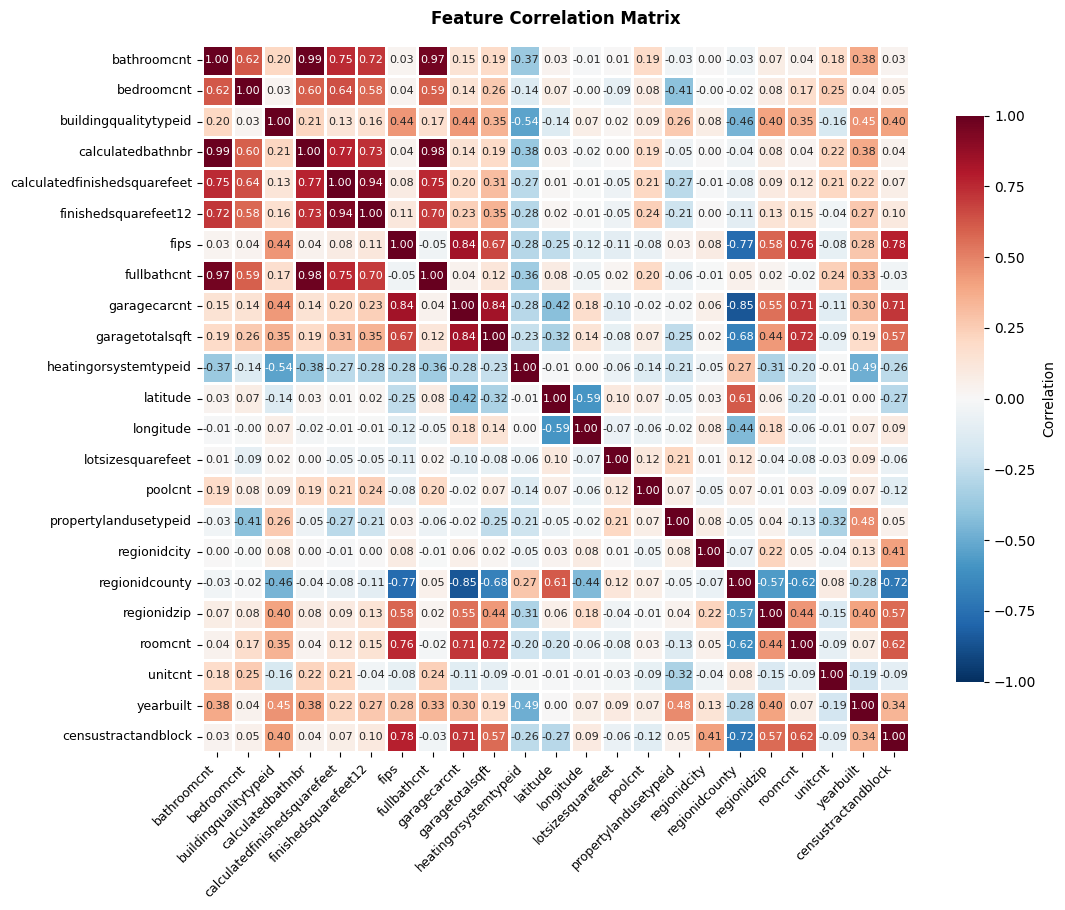


------------------------------------------------------------
CORRELATION MATRIX (Numeric Values):
------------------------------------------------------------
                              bathroomcnt  bedroomcnt  buildingqualitytypeid  calculatedbathnbr  calculatedfinishedsquarefeet  finishedsquarefeet12  fips  fullbathcnt  garagecarcnt  garagetotalsqft  heatingorsystemtypeid  latitude  longitude  lotsizesquarefeet  poolcnt  propertylandusetypeid  regionidcity  regionidcounty  regionidzip  roomcnt  unitcnt  yearbuilt  censustractandblock
bathroomcnt                          1.00        0.62                   0.20               0.99                          0.75                  0.72  0.03         0.97          0.15             0.19                  -0.37      0.03      -0.01               0.01     0.19                  -0.03          0.00           -0.03         0.07     0.04     0.18       0.38                 0.03
bedroomcnt                           0.62        1.00               

In [24]:
# =============================
# 4.A.1: Correlation Matrix with Compact Heatmap
# =============================

print("\n" + "="*80)
print("4.A.1: PAIRWISE CORRELATION MATRIX")
print("="*80)

# Ensure all features are numeric
X_numeric = X.select_dtypes(include=[np.number])
print(f"Analyzing {len(X_numeric.columns)} numeric features")

# Compute correlation matrix
correlation_matrix = X_numeric.corr()

# Create a compact, readable heatmap
plt.figure(figsize=(max(8, len(X_numeric.columns) * 0.5),
                     max(6, len(X_numeric.columns) * 0.4)))

# Use a diverging colormap with limited color steps for clarity
sns.heatmap(correlation_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=1,
            linecolor='white',
            cbar_kws={"shrink": 0.8, "label": "Correlation"},
            annot_kws={"size": 8},
            vmin=-1, vmax=1)

plt.title('Feature Correlation Matrix', fontsize=12, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# Also display as text for reference
print("\n" + "-"*60)
print("CORRELATION MATRIX (Numeric Values):")
print("-"*60)
print(correlation_matrix.round(2).to_string())






4.A.2: F-STATISTIC ANALYSIS
Analyzing 23 numeric features

Checking for missing values...
No missing values found in features

No missing values found in target

Verifying data quality...
Features - any NaN: False
Target - any NaN: False
Data is clean - proceeding with analysis

FEATURE RANKINGS BY F-STATISTIC:
--------------------------------------------------------------------------------
                     Feature  F_Statistic       P_Value  Significant_05  Significant_01
        finishedsquarefeet12 38659.458589  0.000000e+00            True            True
calculatedfinishedsquarefeet 36431.935470  0.000000e+00            True            True
           calculatedbathnbr 22912.183269  0.000000e+00            True            True
                 bathroomcnt 21502.894824  0.000000e+00            True            True
                 fullbathcnt 20254.070107  0.000000e+00            True            True
                  bedroomcnt  5607.504073  0.000000e+00            True      

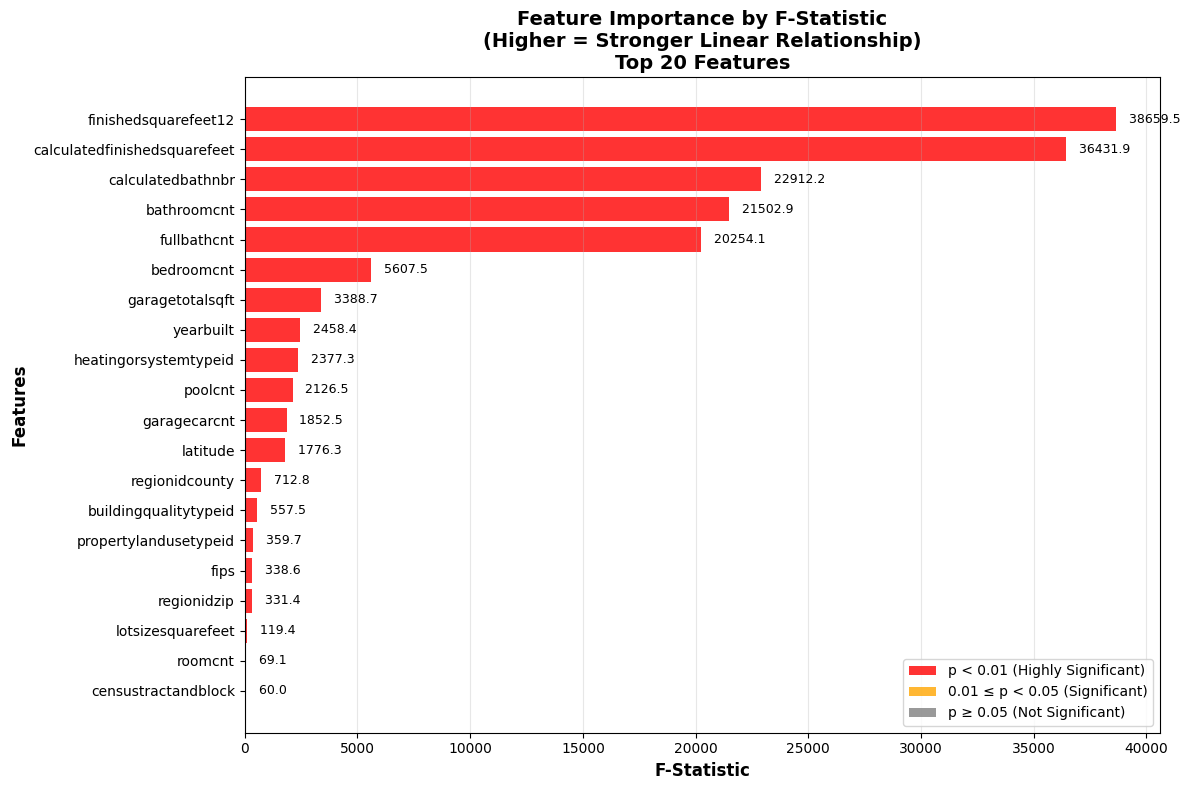


------------------------------------------------------------
F-STATISTIC SUMMARY
------------------------------------------------------------
Total features analyzed: 23
Highly significant features (p < 0.01): 23
Significant features (p < 0.05): 23
Non-significant features (p ≥ 0.05): 0

Top 10 features:
   6. finishedsquarefeet12                F=38659.46 p=0.00e+00 ***
   5. calculatedfinishedsquarefeet        F=36431.94 p=0.00e+00 ***
   4. calculatedbathnbr                   F=22912.18 p=0.00e+00 ***
   1. bathroomcnt                         F=21502.89 p=0.00e+00 ***
   8. fullbathcnt                         F=20254.07 p=0.00e+00 ***
   2. bedroomcnt                          F= 5607.50 p=0.00e+00 ***
  10. garagetotalsqft                     F= 3388.73 p=0.00e+00 ***
  22. yearbuilt                           F= 2458.43 p=0.00e+00 ***
  11. heatingorsystemtypeid               F= 2377.31 p=0.00e+00 ***
  15. poolcnt                             F= 2126.48 p=0.00e+00 ***


In [25]:
# =============================
# 4.A.2: F-Statistic Analysis (with full NaN handling)
# =============================

print("\n" + "="*80)
print("4.A.2: F-STATISTIC ANALYSIS")
print("="*80)

# Ensure we're using numeric features
X_numeric = X.select_dtypes(include=[np.number])
print(f"Analyzing {len(X_numeric.columns)} numeric features")

# Check for NaN values in features
print("\nChecking for missing values...")
nan_counts_X = X_numeric.isnull().sum()
if nan_counts_X.sum() > 0:
    print(f"Found {nan_counts_X.sum()} missing values in features")
    print("Filling NaN values with column means...")
    X_numeric = X_numeric.fillna(X_numeric.mean())
else:
    print("No missing values found in features")

# Check for NaN values in target
nan_count_y = y.isnull().sum()
if nan_count_y > 0:
    print(f"\nFound {nan_count_y} missing values in target variable")
    print("Removing rows with NaN in target...")

    # Create mask of valid rows
    valid_mask = y.notna()

    # Filter both features and target
    X_numeric = X_numeric[valid_mask]
    y = y[valid_mask]

    print(f"Remaining samples: {len(X_numeric)}")
else:
    print("\nNo missing values found in target")

# Verify no NaN remain
print("\nVerifying data quality...")
print(f"Features - any NaN: {X_numeric.isnull().any().any()}")
print(f"Target - any NaN: {y.isnull().any()}")

if X_numeric.isnull().any().any() or y.isnull().any():
    print("ERROR: Still have NaN values. Please check data.")
else:
    print("Data is clean - proceeding with analysis")

# Compute F-statistics and p-values
from sklearn.feature_selection import f_regression
f_scores, p_values = f_regression(X_numeric, y, center=True)

# Create DataFrame for F-statistics
f_stats_df = pd.DataFrame({
    'Feature': X_numeric.columns,
    'F_Statistic': f_scores,
    'P_Value': p_values,
    'Significant_05': p_values < 0.05,
    'Significant_01': p_values < 0.01
}).sort_values('F_Statistic', ascending=False)

# Display F-statistics table
print("\nFEATURE RANKINGS BY F-STATISTIC:")
print("-" * 80)
print(f_stats_df.head(20).to_string(index=False))

# Create bar chart for F-statistics
plt.figure(figsize=(12, max(8, len(f_stats_df) * 0.3)))

# Plot horizontal bar chart (show top 20 if too many features)
n_to_show = min(20, len(f_stats_df))
features_to_plot = f_stats_df.head(n_to_show)['Feature']
f_values_to_plot = f_stats_df.head(n_to_show)['F_Statistic']
colors = ['red' if p < 0.01 else 'orange' if p < 0.05 else 'gray'
          for p in f_stats_df.head(n_to_show)['P_Value']]

bars = plt.barh(range(len(features_to_plot)), f_values_to_plot, color=colors, alpha=0.8)

# Add value labels for top features
for i, (idx, row) in enumerate(f_stats_df.head(n_to_show).iterrows()):
    plt.text(row['F_Statistic'] + max(f_values_to_plot) * 0.01, i,
             f' {row["F_Statistic"]:.1f}',
             va='center', fontsize=9)

plt.yticks(range(len(features_to_plot)), features_to_plot)
plt.xlabel('F-Statistic', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title(f'Feature Importance by F-Statistic\n(Higher = Stronger Linear Relationship)\nTop {n_to_show} Features',
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', alpha=0.8, label='p < 0.01 (Highly Significant)'),
                   Patch(facecolor='orange', alpha=0.8, label='0.01 ≤ p < 0.05 (Significant)'),
                   Patch(facecolor='gray', alpha=0.8, label='p ≥ 0.05 (Not Significant)')]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "-"*60)
print("F-STATISTIC SUMMARY")
print("-"*60)
print(f"Total features analyzed: {len(f_stats_df)}")
print(f"Highly significant features (p < 0.01): {(f_stats_df['P_Value'] < 0.01).sum()}")
print(f"Significant features (p < 0.05): {(f_stats_df['P_Value'] < 0.05).sum()}")
print(f"Non-significant features (p ≥ 0.05): {(f_stats_df['P_Value'] >= 0.05).sum()}")
print(f"\nTop 10 features:")
for i, row in f_stats_df.head(10).iterrows():
    significance = "***" if row['P_Value'] < 0.01 else "**" if row['P_Value'] < 0.05 else "ns"
    print(f"  {i+1:2d}. {row['Feature']:<35} F={row['F_Statistic']:8.2f} p={row['P_Value']:.2e} {significance}")

In [26]:
# Get absolute correlations
corr_pairs = correlation_matrix.abs().unstack()

# Remove duplicate pairs
corr_pairs = corr_pairs[corr_pairs < 1]

# Sort values
strong_corr = corr_pairs.sort_values(ascending=False)

# Show top correlations
strong_corr.head(10)

bathroomcnt                   calculatedbathnbr               0.985814
calculatedbathnbr             bathroomcnt                     0.985814
                              fullbathcnt                     0.982674
fullbathcnt                   calculatedbathnbr               0.982674
                              bathroomcnt                     0.967908
bathroomcnt                   fullbathcnt                     0.967908
calculatedfinishedsquarefeet  finishedsquarefeet12            0.937182
finishedsquarefeet12          calculatedfinishedsquarefeet    0.937182
garagecarcnt                  regionidcounty                  0.853166
regionidcounty                garagecarcnt                    0.853166
dtype: float64

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector

model = LinearRegression()

In [28]:
forward_sfs = SequentialFeatureSelector(
    model,
    n_features_to_select=5,   # change if needed
    direction='forward',
    scoring='r2',
    cv=5
)

forward_sfs.fit(X, y)

forward_features = X.columns[forward_sfs.get_support()]

print("Forward Selected Features:")
print(list(forward_features))

Forward Selected Features:
['calculatedbathnbr', 'finishedsquarefeet12', 'latitude', 'longitude', 'regionidzip']


In [29]:
backward_sfs = SequentialFeatureSelector(
    model,
    n_features_to_select=5,   # keep same for comparison
    direction='backward',
    scoring='r2',
    cv=5
)

backward_sfs.fit(X, y)

backward_features = X.columns[backward_sfs.get_support()]

print("Backward Selected Features:")
print(list(backward_features))

Backward Selected Features:
['bathroomcnt', 'bedroomcnt', 'finishedsquarefeet12', 'latitude', 'regionidzip']


In [30]:
print("Forward Selection:", list(forward_features))
print("Backward Selection:", list(backward_features))

Forward Selection: ['calculatedbathnbr', 'finishedsquarefeet12', 'latitude', 'longitude', 'regionidzip']
Backward Selection: ['bathroomcnt', 'bedroomcnt', 'finishedsquarefeet12', 'latitude', 'regionidzip']


In [31]:
# =============================
# 4.A.3: Identify Strong Correlations
# =============================

print("\n" + "="*80)
print("4.A.3: STRONG FEATURE CORRELATIONS")
print("="*80)

# Flatten correlation matrix
corr_pairs = correlation_matrix.abs().unstack()

# Remove self-correlations
corr_pairs = corr_pairs[corr_pairs < 1]

# Remove duplicate pairs (A-B and B-A)
corr_pairs = corr_pairs.sort_values(ascending=False)
corr_pairs = corr_pairs[~corr_pairs.index.duplicated()]

# Set threshold for "strong" correlation
threshold = 0.8
strong_corr = corr_pairs[corr_pairs > threshold]

print(f"\nStrong correlations (>|{threshold}|):")
print("-" * 60)

if len(strong_corr) == 0:
    print("No strongly correlated feature pairs found.")
else:
    for (feat1, feat2), value in strong_corr.items():
        print(f"{feat1} ↔ {feat2} : {value:.2f}")


4.A.3: STRONG FEATURE CORRELATIONS

Strong correlations (>|0.8|):
------------------------------------------------------------
bathroomcnt ↔ calculatedbathnbr : 0.99
calculatedbathnbr ↔ bathroomcnt : 0.99
calculatedbathnbr ↔ fullbathcnt : 0.98
fullbathcnt ↔ calculatedbathnbr : 0.98
fullbathcnt ↔ bathroomcnt : 0.97
bathroomcnt ↔ fullbathcnt : 0.97
calculatedfinishedsquarefeet ↔ finishedsquarefeet12 : 0.94
finishedsquarefeet12 ↔ calculatedfinishedsquarefeet : 0.94
garagecarcnt ↔ regionidcounty : 0.85
regionidcounty ↔ garagecarcnt : 0.85
fips ↔ garagecarcnt : 0.84
garagecarcnt ↔ fips : 0.84
garagetotalsqft ↔ garagecarcnt : 0.84
garagecarcnt ↔ garagetotalsqft : 0.84


#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships.
 How do the different methods for seeing relationships compare? Do they agree or disagree?



The correlation analysis shows strong multicollinearity among several features, particularly between property size variables (e.g., finishedsquarefeet12 and calculatedfinishedsquarefeet) and bathroom-related features (bathroomcnt, fullbathcnt, calculatedbathnbr). Geographic identifiers such as rawcensustractandblock and fips are perfectly correlated, indicating duplicate information. The F-statistic results highlight that property size, bathroom count, and building characteristics are the most significant predictors of the target variable. Forward and backward selection both identify key features like finishedsquarefeet12 and location-based variables, while differences between them suggest redundancy among highly correlated features.

### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis.
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends.

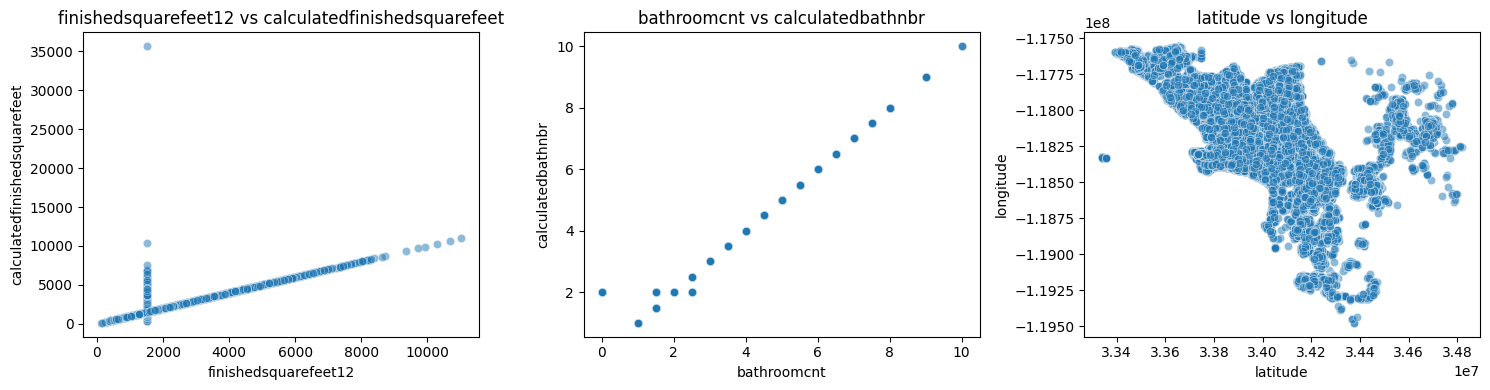

In [32]:
# Select feature pairs based on strong correlations
pairs = [
    ('finishedsquarefeet12', 'calculatedfinishedsquarefeet'),
    ('bathroomcnt', 'calculatedbathnbr'),
    ('latitude', 'longitude')
]

plt.figure(figsize=(15, 4))

for i, (x_col, y_col) in enumerate(pairs, 1):
    plt.subplot(1, 3, i)
    sns.scatterplot(data=df_e, x=x_col, y=y_col, alpha=0.5)
    plt.title(f"{x_col} vs {y_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)

plt.tight_layout()
plt.show()

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.


The scatter plots confirm strong linear relationships between highly correlated features. The relationship between finishedsquarefeet12 and calculatedfinishedsquarefeet shows a near-perfect positive linear trend, indicating they represent similar property size information. Similarly, bathroomcnt and calculatedbathnbr exhibit a strong linear relationship, suggesting redundancy among bathroom-related features. The plot of latitude vs longitude reveals geographic clustering, indicating that location-based features may capture regional patterns in the data.

## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset.
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection).
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary.

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question.

In [33]:
# The DataFrame
df = df.copy()

# Features and target
features = ['bathroomcnt', 'bedroomcnt', 'calculatedfinishedsquarefeet', 'lotsizesquarefeet', 'yearbuilt']
target = 'taxvaluedollarcnt'

In [34]:
def log_transform(df, cols):
    df_log = df.copy()
    for col in cols:
        df_log[col] = np.log1p(df_log[col])  # log1p handles zeros
    return df_log

def polynomial_transform(df, cols):
    df_poly = df.copy()
    for col in cols:
        df_poly[col + '_sq'] = df_poly[col] ** 2
    return df_poly

def ratio_transform(df, col_pairs):
    df_ratio = df.copy()
    for col1, col2 in col_pairs:
        # Avoid division by zero
        df_ratio[col1 + '_div_' + col2] = df_ratio[col1] / df_ratio[col2].replace(0, np.nan)
    return df_ratio

In [35]:
# 1. Log
df_log = log_transform(df, features + [target])

# 2. Polynomial
df_poly = polynomial_transform(df, features)

# 3. Ratios (example: bathroom/bedroom, finished sqft / lot size)
ratio_cols = [('bathroomcnt', 'bedroomcnt'), ('calculatedfinishedsquarefeet', 'lotsizesquarefeet')]
df_ratio = ratio_transform(df, ratio_cols)

In [36]:
print("Correlations after Log Transform:")
print(df_log[features + [target]].corr()[target].sort_values(ascending=False))

print("\nCorrelations for Polynomial Features:")
poly_features = [col for col in df_poly.columns if '_sq' in col]
print(df_poly[poly_features + [target]].corr()[target].sort_values(ascending=False))

print("\nCorrelations for Ratio Features:")
ratio_features = [col for col in df_ratio.columns if '_div_' in col]
print(df_ratio[ratio_features + [target]].corr()[target].sort_values(ascending=False))

Correlations after Log Transform:
taxvaluedollarcnt               1.000000
calculatedfinishedsquarefeet    0.520125
bathroomcnt                     0.445740
yearbuilt                       0.251287
bedroomcnt                      0.228600
lotsizesquarefeet               0.036597
Name: taxvaluedollarcnt, dtype: float64

Correlations for Polynomial Features:
taxvaluedollarcnt                  1.000000
bathroomcnt_sq                     0.551579
calculatedfinishedsquarefeet_sq    0.528889
bedroomcnt_sq                      0.255308
yearbuilt_sq                       0.120308
lotsizesquarefeet_sq              -0.008617
Name: taxvaluedollarcnt, dtype: float64

Correlations for Ratio Features:
taxvaluedollarcnt                                     1.000000
bathroomcnt_div_bedroomcnt                            0.208878
calculatedfinishedsquarefeet_div_lotsizesquarefeet    0.148300
Name: taxvaluedollarcnt, dtype: float64


#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed.


Three feature transformations were applied to better highlight patterns in the data. Logarithmic transformations helped reduce skew in variables like calculatedfinishedsquarefeet and taxvaluedollarcnt, improving their linear relationship with the target. Polynomial features (squares) emphasized differences in numerical variables, slightly increasing correlations for bathroomcnt and calculatedfinishedsquarefeet. Ratio features, such as bathroomcnt/bedroomcnt, captured relative relationships but showed limited impact on correlation. Overall, the log and polynomial transformations were most effective at revealing meaningful patterns that could inform modeling decisions.

## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |



In [37]:
df_e.to_csv("zillow_cleaned.csv", index=False)